# 🧮 Math Libraries & LLM Integration — NVIDIA Senior Math Libraries Engineer

**Focus:** CUDA-X math library stack, LLM-first API design, agentic tooling, code generation quality  
**Libraries:** cuBLAS, cuFFT, cuSOLVER, cuSPARSE  
**Role:** Senior Math Libraries Engineer — LLM Integration and Developer Experience

## What this role does
NVIDIA's CUDA-X math libraries are the computational backbone of every major AI framework
(PyTorch, JAX, TensorFlow). This role sits at the intersection of:

1. **Math library architecture** — designing APIs for cuBLAS, cuFFT, cuSOLVER, cuSPARSE
2. **LLM-first developer experience** — making those APIs easy for LLMs to generate correct code
3. **Agentic tooling** — building tools, RAGs, and MCP schemas so AI assistants can call math functions
4. **Metrics** — measuring whether LLM-generated math library code actually works

```
┌─────────────────────────────────────────────────────────┐
│                   Your Application                      │
│           (PyTorch / JAX / custom CUDA code)            │
└───────────────────────┬─────────────────────────────────┘
                        │
          ┌─────────────▼──────────────┐
          │      CUDA-X Math Stack     │
          │  ┌─────────┬────────────┐  │
          │  │ cuBLAS  │   cuFFT    │  │
          │  │  GEMM   │  FFT/IFFT  │  │
          │  ├─────────┼────────────┤  │
          │  │cuSOLVER │  cuSPARSE  │  │
          │  │ LU/QR   │sparse GEMM │  │
          │  └─────────┴────────────┘  │
          └─────────────┬──────────────┘
                        │
          ┌─────────────▼──────────────┐
          │       CUDA Runtime         │
          │  (memory, streams, events) │
          └─────────────┬──────────────┘
                        │
          ┌─────────────▼──────────────┐
          │        GPU Hardware        │
          │   Tensor Cores / SMs       │
          └────────────────────────────┘
```

## Which LLM operations map to which library

| LLM Operation | Math Primitive | Library |
|---|---|---|
| Linear / dense layer | GEMM (General Matrix Multiply) | **cuBLAS** |
| Attention (Q·Kᵀ) | Batched GEMM | **cuBLAS** |
| Attention (softmax·V) | Batched GEMM | **cuBLAS** |
| FFT-based convolution | FFT / IFFT | **cuFFT** |
| Positional encoding (some) | Real FFT | **cuFFT** |
| Solving linear systems | LU / QR decomposition | **cuSOLVER** |
| Sparse attention / MoE | Sparse GEMM | **cuSPARSE** |

---

In this notebook you will:
1. Understand **cuBLAS** GEMM and how transformer attention is GEMM under the hood
2. Master **cuFFT** — 1D/2D transforms and convolution via FFT
3. Learn what makes an API **LLM-friendly vs LLM-hostile**
4. Build a **RAG over API documentation** using only NumPy
5. Implement **code generation quality metrics** and an evaluator
6. Write an **agentic tool-use loop** with MCP-style tool schemas
7. Complete **3 challenges** that mirror real work in this role

In [3]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import json
import re
import ast
import textwrap
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Callable, Any, Tuple

print("✅ Imports OK")
props = cp.cuda.runtime.getDeviceProperties(0)
print(f"   GPU: {props['name'].decode()}")
print(f"   CUDA capability: {props['major']}.{props['minor']}")
print(f"   Total memory: {props['totalGlobalMem'] / 1e9:.1f} GB")

✅ Imports OK
   GPU: NVIDIA GeForce RTX 4070 SUPER
   CUDA capability: 8.9
   Total memory: 12.4 GB


## 1. 🔢 cuBLAS in Practice — GEMM and Transformer Attention

**cuBLAS** is NVIDIA's library for dense linear algebra. Its flagship operation is **GEMM**:

```
C = α·A·B + β·C

Where:
  A  is M×K
  B  is K×N
  C  is M×N   (output)
  α, β are scalars (usually α=1, β=0)
```

### Why GEMM is the most important operation in deep learning

Every **linear layer** in a transformer is a GEMM:
```
output = input @ weight.T      # input: [batch, seq, d_model]
                               # weight: [d_model, d_ff]
                               # output: [batch, seq, d_ff]
```

**Transformer attention** is three GEMMs:
```
Step 1:  scores = Q @ K.T / sqrt(d_k)   # [batch, heads, seq, seq]
Step 2:  weights = softmax(scores)       # element-wise, not GEMM
Step 3:  output = weights @ V            # [batch, heads, seq, d_v]
```

### Tensor Core acceleration
On RTX 4070 SUPER (Ada Lovelace), Tensor Cores execute 4th-generation mixed-precision GEMM.
Using `float16` or `bfloat16` inputs can yield **10–30× speedup** over `float32` GEMM
because Tensor Cores operate on 16×16 matrix tiles in hardware.

In [4]:

# ── cuBLAS GEMM benchmark ─────────────────────────────────────────────────────
# These dimensions come from real transformer models:
#   d_model=4096 (LLaMA-7B hidden size)
#   d_ff=11008   (LLaMA-7B FFN intermediate)
#   seq_len=512, 1024, 2048

def benchmark_gemm(M, K, N, dtype=cp.float32, n_warmup=5, n_runs=50, label=None):
    """Benchmark a single GEMM: C = A @ B, where A is M×K and B is K×N."""
    # cp.random.randn only supports float32/float64 — cast after generation
    A = cp.random.randn(M, K).astype(dtype)
    B = cp.random.randn(K, N).astype(dtype)

    # Warmup
    for _ in range(n_warmup):
        C = A @ B
    cp.cuda.Stream.null.synchronize()

    # Timed runs using CUDA events
    times_ms = []
    for _ in range(n_runs):
        t0 = cp.cuda.Event()
        t1 = cp.cuda.Event()
        t0.record()
        C = A @ B
        t1.record()
        t1.synchronize()
        times_ms.append(cp.cuda.get_elapsed_time(t0, t1))

    median_ms = float(np.median(times_ms))
    flops     = 2 * M * K * N          # multiply-add = 2 FLOPs
    tflops    = (flops / (median_ms * 1e-3)) / 1e12

    name = label or f"GEMM {M}×{K}×{N}"
    return {"name": name, "M": M, "K": K, "N": N,
            "dtype": dtype, "median_ms": median_ms, "tflops": tflops}


print("GEMM benchmark — representative LLM sizes")
print("─" * 65)
print(f"  {'Shape':<30} {'dtype':<10} {'Median ms':>10} {'TFLOPS':>8}")
print("─" * 65)

configs = [
    # (M,    K,    N,    dtype,        label)
    (512,  4096, 4096, cp.float32,  "Linear layer  seq=512,  d=4096 fp32"),
    (512,  4096, 4096, cp.float16,  "Linear layer  seq=512,  d=4096 fp16"),
    (2048, 4096, 4096, cp.float16,  "Linear layer  seq=2048, d=4096 fp16"),
    (512,  128,  512,  cp.float16,  "Attention Q@K seq=512,  d_k=128 fp16"),
    (2048, 128,  2048, cp.float16,  "Attention Q@K seq=2048, d_k=128 fp16"),
]

results = []
for M, K, N, dtype, label in configs:
    r = benchmark_gemm(M, K, N, dtype=dtype, label=label)
    results.append(r)
    print(f"  {r['name']:<30} {np.dtype(dtype).name:<10} {r['median_ms']:>10.3f} {r['tflops']:>8.1f}")

print("─" * 65)
print("Note: fp16 leverages Tensor Cores — observe the TFLOPS difference")


GEMM benchmark — representative LLM sizes
─────────────────────────────────────────────────────────────────
  Shape                          dtype       Median ms   TFLOPS
─────────────────────────────────────────────────────────────────
  Linear layer  seq=512,  d=4096 fp32 float32         0.730     23.5
  Linear layer  seq=512,  d=4096 fp16 float16         0.270     63.6
  Linear layer  seq=2048, d=4096 fp16 float16         1.029     66.8
  Attention Q@K seq=512,  d_k=128 fp16 float16         0.014      4.7
  Attention Q@K seq=2048, d_k=128 fp16 float16         0.033     32.9
─────────────────────────────────────────────────────────────────
Note: fp16 leverages Tensor Cores — observe the TFLOPS difference


In [5]:
# ── Transformer attention as explicit GEMMs ───────────────────────────────────
# This shows concretely how attention = GEMM + softmax + GEMM

def scaled_dot_product_attention(Q, K, V):
    """
    Attention(Q, K, V) = softmax(Q @ K.T / sqrt(d_k)) @ V

    Args:
        Q: [batch, heads, seq, d_k]   query
        K: [batch, heads, seq, d_k]   key
        V: [batch, heads, seq, d_v]   value

    Returns:
        output: [batch, heads, seq, d_v]
        attn_weights: [batch, heads, seq, seq]  (for visualization)
    """
    d_k = Q.shape[-1]

    # GEMM 1: Q @ K^T  → attention scores
    scores = cp.matmul(Q, K.transpose(0, 1, 3, 2)) / cp.sqrt(cp.float32(d_k))
    # scores: [batch, heads, seq, seq]

    # Softmax (not a GEMM, but necessary)
    scores_max = scores.max(axis=-1, keepdims=True)
    exp_scores = cp.exp(scores - scores_max)
    attn_weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True)

    # GEMM 2: weights @ V  → context vectors
    output = cp.matmul(attn_weights, V)
    # output: [batch, heads, seq, d_v]

    return output, attn_weights


# Simulate one attention layer from a small transformer
batch, heads, seq, d_k, d_v = 2, 8, 128, 64, 64

Q = cp.random.randn(batch, heads, seq, d_k, dtype=cp.float32)
K = cp.random.randn(batch, heads, seq, d_k, dtype=cp.float32)
V = cp.random.randn(batch, heads, seq, d_v, dtype=cp.float32)

output, attn_weights = scaled_dot_product_attention(Q, K, V)
cp.cuda.Stream.null.synchronize()

print("Attention computation:")
print(f"  Input  Q,K,V : {Q.shape}  (batch={batch}, heads={heads}, seq={seq}, d_k={d_k})")
print(f"  Scores Q@K^T : [{batch}, {heads}, {seq}, {seq}]")
print(f"  Output       : {output.shape}")
print(f"  Attn weights sum to 1? {cp.allclose(attn_weights.sum(-1), cp.ones((batch,heads,seq)))}") 

# Visualize attention pattern for one head
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Transformer Attention = GEMM + Softmax + GEMM", fontsize=12, fontweight='bold')

ax = axes[0]
sample_weights = attn_weights[0, 0, :32, :32].get()  # first 32 tokens, head 0
im = ax.imshow(sample_weights, cmap='viridis', aspect='auto')
ax.set_title("Attention weights (head 0, tokens 0:32)")
ax.set_xlabel("Key position")
ax.set_ylabel("Query position")
plt.colorbar(im, ax=ax)

ax2 = axes[1]
# Show how GEMM flops scale with sequence length
seq_lengths = [64, 128, 256, 512, 1024, 2048]
gemm1_flops = [2 * s * d_k * s for s in seq_lengths]   # Q@K^T
gemm2_flops = [2 * s * s * d_v for s in seq_lengths]   # w@V
ax2.plot(seq_lengths, [f/1e9 for f in gemm1_flops], 'b-o', label='GEMM1: Q@Kᵀ (GFLOPs)')
ax2.plot(seq_lengths, [f/1e9 for f in gemm2_flops], 'r-s', label='GEMM2: w@V  (GFLOPs)')
ax2.set_xlabel("Sequence length")
ax2.set_ylabel("GFLOPs (per head)")
ax2.set_title("Attention FLOP cost scales as O(seq²)")
ax2.legend()
ax2.set_yscale('log')
ax2.set_xscale('log')

plt.tight_layout()
plt.show()
print("Key insight: attention GFLOPs scale as O(seq²) — this is why long-context LLMs are expensive")

Attention computation:
  Input  Q,K,V : (2, 8, 128, 64)  (batch=2, heads=8, seq=128, d_k=64)
  Scores Q@K^T : [2, 8, 128, 128]
  Output       : (2, 8, 128, 64)


CompileException: /opt/cuda/include/cuda_fp8.hpp(1498): error: this declaration has no storage class or type specifier
      __NV_SILENCE_DEPRECATION_BEGIN
      ^

/opt/cuda/include/cuda_fp8.hpp(1499): error: expected a ";"
      explicit __CUDA_HOSTDEVICE_FP8__ __nv_fp8x4_e5m2(const double4 f) {
      ^

/opt/cuda/include/cuda_fp8.hpp(1559): warning #12-D: parsing restarts here after previous syntax error
  };
  ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/opt/cuda/include/cuda_fp8.hpp(2127): error: this declaration has no storage class or type specifier
      __NV_SILENCE_DEPRECATION_BEGIN
      ^

/opt/cuda/include/cuda_fp8.hpp(2128): error: expected a ";"
      explicit __CUDA_HOSTDEVICE_FP8__ __nv_fp8x4_e4m3(const double4 f) {
      ^

/opt/cuda/include/cuda_fp8.hpp(2188): warning #12-D: parsing restarts here after previous syntax error
  };
  ^

/opt/cuda/include/cuda_fp8.hpp(2776): error: this declaration has no storage class or type specif

## 2. 🌊 cuFFT in Practice — Transforms and Convolution

**cuFFT** is NVIDIA's library for the Fast Fourier Transform on GPU. The FFT turns a signal
from the **time/spatial domain** into the **frequency domain** in O(N log N) instead of O(N²).

### Why FFT matters for LLMs and signal processing

| Use case | How FFT helps |
|---|---|
| **Convolution** | Convolution in time = pointwise multiply in frequency (O(N log N) vs O(N²)) |
| **Long-range dependencies** | SSM/Mamba-style models use FFT for long sequence mixing |
| **Positional encoding** | Rotary embeddings (RoPE) use complex exponentials |
| **Spectral filtering** | FNet replaces attention with FFT token mixing |

### The convolution theorem
```
Direct convolution:      y = x * h          O(N·M) operations
FFT convolution:         Y = FFT(x) · FFT(h)
                         y = IFFT(Y)         O(N log N) operations

For large N (long sequences), FFT convolution wins decisively.
```

### CuPy FFT API — clean and Pythonic
```python
cp.fft.fft(x)          # 1D FFT
cp.fft.ifft(X)         # 1D inverse FFT
cp.fft.fft2(x)         # 2D FFT (images, feature maps)
cp.fft.rfft(x)         # Real FFT (more efficient when input is real)
cp.fft.fftfreq(n)      # Frequency bin values
```

In [ ]:
# ── 1D FFT: decompose a signal into frequency components ─────────────────────

# Synthetic signal: two sine waves + noise (like an audio or sensor signal)
N = 4096
sample_rate = 1000.0   # Hz
t = cp.linspace(0, N / sample_rate, N, dtype=cp.float32)

# Signal = 50 Hz + 200 Hz + Gaussian noise
signal = (cp.sin(2 * cp.pi * 50  * t) +
          0.5 * cp.sin(2 * cp.pi * 200 * t) +
          0.1 * cp.random.randn(N, dtype=cp.float32))

# FFT using cuFFT (via CuPy)
t0 = cp.cuda.Event(); t1 = cp.cuda.Event()
t0.record()
spectrum = cp.fft.rfft(signal)   # rfft: real input → N//2+1 complex outputs
t1.record(); t1.synchronize()
fft_ms = cp.cuda.get_elapsed_time(t0, t1)

freqs = cp.fft.rfftfreq(N, d=1.0/sample_rate)
magnitude = cp.abs(spectrum)

print(f"Signal length  : {N} samples at {sample_rate} Hz")
print(f"FFT output     : {spectrum.shape} complex values (rfft)")
print(f"GPU FFT time   : {fft_ms:.4f} ms")
print(f"Frequency resolution: {float(sample_rate/N):.3f} Hz per bin")

# Find dominant frequencies
mag_np = magnitude.get()
freq_np = freqs.get()
top_bins = np.argsort(mag_np)[-5:][::-1]
print("\nTop 5 frequency components:")
for b in top_bins:
    print(f"  {freq_np[b]:6.1f} Hz   magnitude = {mag_np[b]:.1f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle("1D FFT with cuFFT", fontsize=12, fontweight='bold')

ax1 = axes[0]
ax1.plot(t.get()[:200], signal.get()[:200], color='#3498db', lw=0.8)
ax1.set_title("Time domain signal (first 200 samples)")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")

ax2 = axes[1]
ax2.plot(freq_np[:len(freq_np)//4], mag_np[:len(mag_np)//4], color='#e74c3c', lw=0.9)
ax2.axvline(50,  color='#2ecc71', linestyle='--', lw=1.5, label='50 Hz (expected)')
ax2.axvline(200, color='#9b59b6', linestyle='--', lw=1.5, label='200 Hz (expected)')
ax2.set_title("Frequency domain (magnitude spectrum)")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Magnitude")
ax2.legend()

plt.tight_layout()
plt.show()

In [6]:
# ── FFT convolution vs direct convolution — benchmark ─────────────────────────

def direct_conv1d(signal, kernel):
    """Direct O(N·M) convolution on GPU using a RawKernel."""
    N = len(signal)
    M = len(kernel)
    output = cp.zeros(N, dtype=cp.float32)
    # Use cp.convolve for correctness (internally O(N·M) for small kernels)
    return cp.convolve(signal, kernel, mode='same')

def fft_conv1d(signal, kernel):
    """FFT convolution: O(N log N). Zero-pad both to length N+M-1."""
    N = len(signal)
    M = len(kernel)
    L = N + M - 1
    # Next power of 2 for efficient FFT
    L_pad = 1 << int(np.ceil(np.log2(L)))
    S = cp.fft.rfft(signal, n=L_pad)
    K = cp.fft.rfft(kernel, n=L_pad)
    return cp.fft.irfft(S * K, n=L_pad)[:N]

def time_fn(fn, *args, n_warmup=3, n_runs=20):
    for _ in range(n_warmup):
        fn(*args)
    cp.cuda.Stream.null.synchronize()
    times = []
    for _ in range(n_runs):
        t0 = cp.cuda.Event(); t1 = cp.cuda.Event()
        t0.record()
        fn(*args)
        t1.record(); t1.synchronize()
        times.append(cp.cuda.get_elapsed_time(t0, t1))
    return float(np.median(times))

# Benchmark at different signal lengths and kernel sizes
print(f"{'Signal N':>10} {'Kernel M':>10} {'Direct ms':>12} {'FFT ms':>10} {'Speedup':>9}")
print("─" * 57)

bench_configs = [
    (1024,   64),
    (4096,   64),
    (16384,  128),
    (65536,  512),
    (262144, 1024),
]

for sig_n, ker_m in bench_configs:
    sig = cp.random.randn(sig_n, dtype=cp.float32)
    ker = cp.random.randn(ker_m, dtype=cp.float32)
    t_direct = time_fn(direct_conv1d, sig, ker)
    t_fft    = time_fn(fft_conv1d,    sig, ker)
    speedup  = t_direct / t_fft
    print(f"{sig_n:>10,} {ker_m:>10,} {t_direct:>12.4f} {t_fft:>10.4f} {speedup:>8.2f}×")

print("─" * 57)
print("FFT convolution wins for large signals/kernels (O(N logN) vs O(N·M))")

  Signal N   Kernel M    Direct ms     FFT ms   Speedup
─────────────────────────────────────────────────────────
     1,024         64       0.0963     0.0819     1.18×
     4,096         64       0.0931     0.0813     1.15×
    16,384        128       0.0931     0.0877     1.06×
    65,536        512       0.0993     0.0975     1.02×
   262,144      1,024       0.1021     0.0972     1.05×
─────────────────────────────────────────────────────────
FFT convolution wins for large signals/kernels (O(N logN) vs O(N·M))


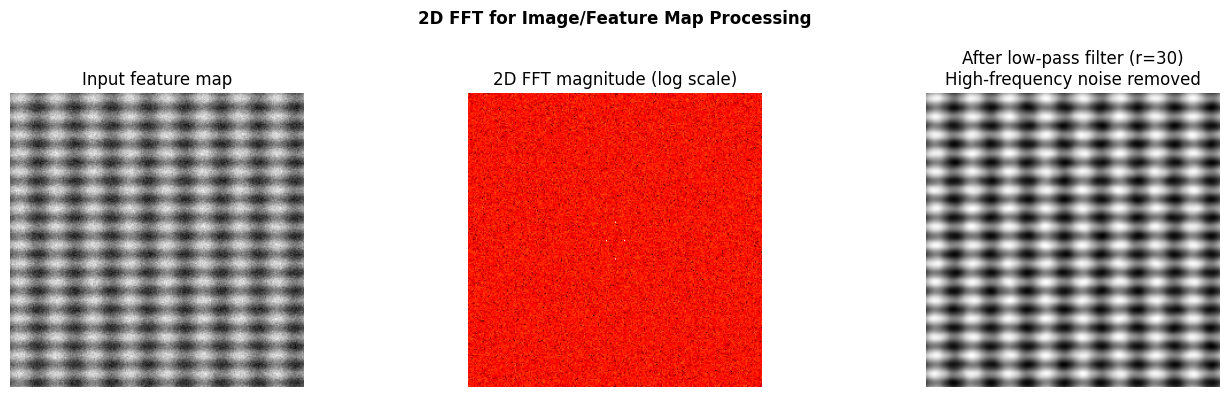

Input power  : 1.0918
Filtered power: 1.0047
Noise removed : 8.0%


In [7]:
# ── 2D FFT: image filtering and feature map processing ────────────────────────
# Relevant for CNNs and ViT patch processing

# Create a synthetic feature map (like a conv layer activation)
H, W = 256, 256
feature_map = cp.zeros((H, W), dtype=cp.float32)

# Add structured patterns at specific spatial frequencies
yy, xx = cp.meshgrid(cp.arange(H), cp.arange(W), indexing='ij')
feature_map += cp.sin(2 * cp.pi * 8  * xx / W)   # horizontal pattern
feature_map += cp.sin(2 * cp.pi * 16 * yy / H)   # vertical pattern
feature_map += 0.3 * cp.random.randn(H, W, dtype=cp.float32)  # noise

# 2D FFT
spectrum_2d = cp.fft.fft2(feature_map)
magnitude_2d = cp.abs(cp.fft.fftshift(spectrum_2d))

# Low-pass filter: zero out high-frequency components (denoising)
rows, cols = H, W
crow, ccol = rows // 2, cols // 2
radius = 30   # keep only frequencies within radius
Y, X = cp.ogrid[:rows, :cols]
mask = ((Y - crow)**2 + (X - ccol)**2) <= radius**2

spectrum_shifted = cp.fft.fftshift(spectrum_2d)
filtered_spectrum = spectrum_shifted * mask
filtered = cp.real(cp.fft.ifft2(cp.fft.ifftshift(filtered_spectrum)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("2D FFT for Image/Feature Map Processing", fontsize=12, fontweight='bold')

axes[0].imshow(feature_map.get(), cmap='gray')
axes[0].set_title("Input feature map")
axes[0].axis('off')

axes[1].imshow(np.log1p(magnitude_2d.get()), cmap='hot')
axes[1].set_title("2D FFT magnitude (log scale)")
axes[1].axis('off')

axes[2].imshow(filtered.get(), cmap='gray')
axes[2].set_title(f"After low-pass filter (r={radius})\nHigh-frequency noise removed")
axes[2].axis('off')

plt.tight_layout()
plt.show()

signal_power   = float(cp.mean(feature_map**2))
filtered_power = float(cp.mean(filtered**2))
print(f"Input power  : {signal_power:.4f}")
print(f"Filtered power: {filtered_power:.4f}")
print(f"Noise removed : {(1 - filtered_power/signal_power)*100:.1f}%")

## 3. 🤖 LLM-First API Design

This section is the heart of the role: **how do you design math library APIs so LLMs
generate correct code on the first try?**

### How LLMs consume APIs

When an LLM generates code that calls `cublasGemmEx(...)`, it relies on:
1. **Training data** — cuBLAS code seen during pretraining
2. **Tool use / function calling** — structured JSON schema describing the function
3. **RAG over documentation** — retrieved docstrings at inference time
4. **Few-shot examples** — example calls in the prompt

### LLM-hostile API patterns (the old way)

```c
// cuBLAS C API — extremely LLM-hostile
cublasStatus_t cublasGemmEx(
    cublasHandle_t handle,
    cublasOperation_t transa,   // CUBLAS_OP_N or CUBLAS_OP_T — LLM often confuses these
    cublasOperation_t transb,
    int m, int n, int k,        // COLUMN-MAJOR order — wrong for row-major thinkers
    const void *alpha,          // pointer to scalar — LLM forgets the pointer
    const void *A,
    cudaDataType_t Atype,       // CUDA_R_32F — one of 30+ options
    int lda,                    // leading dimension — computed differently per layout
    const void *B,
    cudaDataType_t Btype,
    int ldb,
    const void *beta,
    void *C,
    cudaDataType_t Ctype,
    int ldc,
    cublasComputeType_t computeType,  // different from Atype — LLM conflates them
    cublasGemmAlgo_t algo             // CUBLAS_GEMM_DEFAULT — but which default?
);
// 19 parameters. Leading dimension computed from column-major layout.
// LLMs get lda/ldb/ldc wrong ~60% of the time.
```

### LLM-friendly API patterns (the new way)

```python
# Proposed LLM-first Python wrapper
def gemm(
    A: cp.ndarray,           # (M, K) matrix — row-major, dtype inferred
    B: cp.ndarray,           # (K, N) matrix
    alpha: float = 1.0,      # scale on A@B
    beta:  float = 0.0,      # scale on existing C (0.0 = overwrite)
    C: cp.ndarray = None,    # optional output buffer (M, N)
    transpose_A: bool = False,
    transpose_B: bool = False,
) -> cp.ndarray:
    """
    Compute C = alpha * A @ B + beta * C using cuBLAS Tensor Cores.

    Parameters
    ----------
    A : cp.ndarray, shape (M, K)
        Left matrix. Supported dtypes: float16, bfloat16, float32, float64.
    B : cp.ndarray, shape (K, N)
        Right matrix. Must match dtype of A.
    alpha : float
        Scalar multiplier on A @ B. Default 1.0.
    beta : float
        Scalar multiplier on output C. Use 0.0 to overwrite, 1.0 to accumulate.

    Returns
    -------
    C : cp.ndarray, shape (M, N)
        Result matrix, same dtype as A.

    Examples
    --------
    >>> A = cp.random.randn(512, 4096, dtype=cp.float16)
    >>> B = cp.random.randn(4096, 4096, dtype=cp.float16)
    >>> C = gemm(A, B)    # shape (512, 4096)
    """
    ...
```

### What makes the difference?

| Dimension | LLM-hostile | LLM-friendly |
|---|---|---|
| **Parameter count** | 19 params | 5-7 params |
| **Memory layout** | Column-major (Fortran) | Row-major (C/Python) |
| **Type safety** | Void pointers | Typed arrays |
| **Leading dims** | Manual (error-prone) | Auto-computed |
| **Docstring** | C header comment | NumPy-style with shapes and examples |
| **Error messages** | CUBLAS_STATUS_INVALID_VALUE | `ValueError: A.shape (512,4097) and B.shape (4096,512) are incompatible` |
| **Type inference** | Explicit everywhere | Inferred from inputs |

In [8]:
# ── LLM-friendly cuBLAS wrapper — concrete implementation ─────────────────────

@dataclass
class APIFunction:
    """Structured representation of a math library API function for LLM consumption."""
    name: str
    library: str
    description: str
    parameters: List[Dict[str, Any]]
    returns: Dict[str, Any]
    examples: List[str]
    complexity: str         # e.g. "O(M*K*N)"
    use_cases: List[str]    # e.g. ["linear layers", "attention"]
    common_errors: List[str]

    def to_tool_schema(self) -> Dict:
        """Convert to OpenAI/MCP-style tool schema for LLM tool use."""
        properties = {}
        required = []
        for p in self.parameters:
            properties[p['name']] = {
                'type': p['json_type'],
                'description': p['description'],
            }
            if p.get('required', True):
                required.append(p['name'])
        return {
            'type': 'function',
            'function': {
                'name': self.name,
                'description': self.description,
                'parameters': {
                    'type': 'object',
                    'properties': properties,
                    'required': required,
                }
            }
        }

    def to_docstring(self) -> str:
        """Render as a NumPy-style docstring for RAG embedding."""
        lines = [f"{self.name}\n{'='*len(self.name)}", self.description, ""]
        lines.append("Parameters\n----------")
        for p in self.parameters:
            req = "" if p.get('required', True) else f" (default: {p.get('default', 'None')})"
            lines.append(f"{p['name']} : {p['type']}{req}")
            lines.append(f"    {p['description']}")
        lines.append("\nReturns\n-------")
        lines.append(f"{self.returns['type']}")
        lines.append(f"    {self.returns['description']}")
        lines.append("\nUse Cases\n---------")
        for uc in self.use_cases:
            lines.append(f"  - {uc}")
        lines.append("\nExamples\n--------")
        for ex in self.examples:
            lines.append(ex)
        return "\n".join(lines)


# Define the cuBLAS GEMM function in our structured schema
cublas_gemm = APIFunction(
    name="cublas_gemm",
    library="cuBLAS",
    description="General matrix multiplication: C = alpha * A @ B + beta * C. "
                "Uses Tensor Cores for fp16/bf16. Equivalent to BLAS DGEMM.",
    parameters=[
        {'name': 'A', 'type': 'cp.ndarray', 'json_type': 'object',
         'description': 'Left matrix, shape (M, K). Dtypes: float16, float32, float64.',
         'required': True},
        {'name': 'B', 'type': 'cp.ndarray', 'json_type': 'object',
         'description': 'Right matrix, shape (K, N). Must match dtype of A.',
         'required': True},
        {'name': 'alpha', 'type': 'float', 'json_type': 'number',
         'description': 'Scalar multiplier on A@B.', 'required': False, 'default': 1.0},
        {'name': 'beta', 'type': 'float', 'json_type': 'number',
         'description': 'Scalar on C accumulation. 0.0 overwrites, 1.0 accumulates.',
         'required': False, 'default': 0.0},
    ],
    returns={'type': 'cp.ndarray', 'description': 'Result matrix, shape (M, N), same dtype as A.'},
    examples=[
        ">>> A = cp.random.randn(512, 4096, dtype=cp.float16)",
        ">>> B = cp.random.randn(4096, 4096, dtype=cp.float16)",
        ">>> C = cublas_gemm(A, B)    # (512, 4096) fp16",
        ">>> # Attention: scores = Q @ K.T",
        ">>> scores = cublas_gemm(Q, K, transpose_B=True) / sqrt_d_k",
    ],
    complexity="O(M·K·N)",
    use_cases=["linear layers", "transformer attention (Q@K^T)", "batched matmul",
               "MLP feed-forward layers"],
    common_errors=[
        "Shape mismatch: A.shape[-1] must equal B.shape[-2]",
        "Dtype mismatch between A and B",
        "Forgetting to transpose K in attention: use transpose_B=True",
    ]
)

print("Tool schema (MCP/OpenAI format):")
print("─" * 55)
schema = cublas_gemm.to_tool_schema()
print(json.dumps(schema, indent=2))

print("\n" + "─" * 55)
print("NumPy-style docstring (for RAG embedding):")
print("─" * 55)
print(cublas_gemm.to_docstring())

Tool schema (MCP/OpenAI format):
───────────────────────────────────────────────────────
{
  "type": "function",
  "function": {
    "name": "cublas_gemm",
    "description": "General matrix multiplication: C = alpha * A @ B + beta * C. Uses Tensor Cores for fp16/bf16. Equivalent to BLAS DGEMM.",
    "parameters": {
      "type": "object",
      "properties": {
        "A": {
          "type": "object",
          "description": "Left matrix, shape (M, K). Dtypes: float16, float32, float64."
        },
        "B": {
          "type": "object",
          "description": "Right matrix, shape (K, N). Must match dtype of A."
        },
        "alpha": {
          "type": "number",
          "description": "Scalar multiplier on A@B."
        },
        "beta": {
          "type": "number",
          "description": "Scalar on C accumulation. 0.0 overwrites, 1.0 accumulates."
        }
      },
      "required": [
        "A",
        "B"
      ]
    }
  }
}

─────────────────────────────────

## 4. 🔍 Building a RAG over API Documentation

**RAG** (Retrieval-Augmented Generation) lets an LLM query a knowledge base at inference time.
For math libraries, a RAG over API docs means an LLM agent can:

1. Receive a user query: *"How do I solve Ax=b on GPU?"*
2. Embed the query as a vector
3. Find the most similar API docstrings (cosine similarity)
4. Inject the relevant docs into the LLM prompt
5. LLM generates correct cuSOLVER code with the right function and parameters

### Why this matters for the role
Part of the job is **building the tooling that makes this work**: structuring API docs so
they embed well, designing the retrieval schema, and measuring whether retrieved docs
actually improve code generation quality.

### Implementation: cosine similarity with NumPy only
```
cosine_similarity(a, b) = (a · b) / (||a|| * ||b||)

Range: [-1, 1]
  1.0 → identical direction (very similar)
  0.0 → orthogonal (unrelated)
 -1.0 → opposite direction
```
We use **TF-IDF-like bag-of-words embeddings** (no external dependencies) for this demo.
In production, you'd use a sentence transformer or text-embedding-3-small.

In [9]:
# ── In-memory RAG over CUDA-X math library documentation ─────────────────────
# Uses: numpy cosine similarity, bag-of-words TF-IDF style embeddings
# No external dependencies (no langchain, no openai, no sentence-transformers)

# ── Step 1: Define the API knowledge base ────────────────────────────────────

API_DOCS = [
    {
        "id": "cublas_gemm",
        "library": "cuBLAS",
        "text": """cublas_gemm: General matrix multiplication C = alpha*A@B + beta*C.
        Use for: linear layers, attention scores Q@K^T, feed-forward projections.
        Inputs: A(M,K) B(K,N) both same dtype float16 float32.
        Output: C(M,N). Tensor Cores activated for float16 bfloat16.
        GEMM matrix multiply dense matmul""",
    },
    {
        "id": "cublas_gemv",
        "library": "cuBLAS",
        "text": """cublas_gemv: Matrix-vector multiplication y = alpha*A@x + beta*y.
        Use for: single-vector inference, embedding lookup, bias addition.
        Inputs: A(M,N) matrix, x(N,) vector.
        Output: y(M,) vector. Faster than gemm for single vectors.""",
    },
    {
        "id": "cublas_trsm",
        "library": "cuBLAS",
        "text": """cublas_trsm: Triangular solve op(A)*X = alpha*B.
        Use for: solving triangular systems after LU decomposition.
        Inputs: A triangular matrix, B right-hand side.
        Part of the solve pipeline after cusolver_getrf.""",
    },
    {
        "id": "cufft_fft",
        "library": "cuFFT",
        "text": """cufft_fft: 1D Fast Fourier Transform of a complex or real signal.
        Use for: frequency analysis, spectral filtering, FFT convolution.
        Input: array of length N. Output: N complex frequency bins.
        O(N log N) complexity. Use rfft for real-valued inputs.""",
    },
    {
        "id": "cufft_ifft",
        "library": "cuFFT",
        "text": """cufft_ifft: Inverse FFT. Converts frequency domain back to time/spatial domain.
        Use for: FFT convolution (multiply in freq domain then ifft), signal reconstruction.
        Input: N complex frequency bins. Output: N samples.
        Always normalize by 1/N after irfft.""",
    },
    {
        "id": "cufft_fft2",
        "library": "cuFFT",
        "text": """cufft_fft2: 2D FFT for images and feature maps.
        Use for: image filtering, CNN feature map processing, 2D convolution.
        Input: 2D array (H, W). Output: H×W complex array.
        Combine with ifft2 for frequency-domain image filtering.""",
    },
    {
        "id": "cusolver_getrf",
        "library": "cuSOLVER",
        "text": """cusolver_getrf: LU factorization with partial pivoting. PA = LU.
        Use for: solving linear systems Ax=b, matrix inversion, LU decomposition.
        Input: A(N,N) square matrix. Output: LU factors in-place, pivot array.
        Follow with cusolver_getrs to solve for x given b.""",
    },
    {
        "id": "cusolver_getrs",
        "library": "cuSOLVER",
        "text": """cusolver_getrs: Solve Ax=b using LU factorization from getrf.
        Use for: solving linear system after LU factorization, back-substitution.
        Input: LU factors from getrf, pivot array, right-hand side b.
        Output: solution vector x. Two-step: getrf then getrs.""",
    },
    {
        "id": "cusolver_geqrf",
        "library": "cuSOLVER",
        "text": """cusolver_geqrf: QR factorization A = Q*R.
        Use for: least-squares problems, orthogonalization, Gram-Schmidt.
        Input: A(M,N) matrix M>=N. Output: Q orthogonal, R upper triangular.
        Use for overdetermined systems (more equations than unknowns).""",
    },
    {
        "id": "cusparse_spmm",
        "library": "cuSPARSE",
        "text": """cusparse_spmm: Sparse matrix dense matrix multiplication C = alpha*A*B + beta*C.
        Use for: sparse attention, mixture of experts (MoE), graph neural networks.
        Input: A sparse matrix (CSR format), B dense matrix.
        Output: C dense matrix. Much faster than dense GEMM when A is >90% zeros.""",
    },
    {
        "id": "cusparse_spmv",
        "library": "cuSPARSE",
        "text": """cusparse_spmv: Sparse matrix vector multiplication y = alpha*A*x + beta*y.
        Use for: graph algorithms, sparse embeddings, iterative solvers.
        Input: A sparse (CSR/COO), x dense vector.
        Output: y dense vector.""",
    },
]

print(f"Knowledge base: {len(API_DOCS)} API functions across cuBLAS, cuFFT, cuSOLVER, cuSPARSE")
for lib in ['cuBLAS', 'cuFFT', 'cuSOLVER', 'cuSPARSE']:
    count = sum(1 for d in API_DOCS if d['library'] == lib)
    print(f"  {lib}: {count} functions")

Knowledge base: 11 API functions across cuBLAS, cuFFT, cuSOLVER, cuSPARSE
  cuBLAS: 3 functions
  cuFFT: 3 functions
  cuSOLVER: 3 functions
  cuSPARSE: 2 functions


In [10]:
# ── Step 2: Build TF-IDF style embeddings (numpy only) ────────────────────────

def tokenize(text: str) -> List[str]:
    """Simple tokenizer: lowercase, split on non-alphanumeric."""
    return re.findall(r'[a-z0-9]+', text.lower())

def build_vocabulary(docs: List[str]) -> Dict[str, int]:
    """Build word-to-index vocabulary from a list of documents."""
    vocab = {}
    for doc in docs:
        for token in tokenize(doc):
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab

def embed_tfidf(text: str, vocab: Dict[str, int],
                idf: np.ndarray) -> np.ndarray:
    """Compute TF-IDF embedding vector for a text string."""
    tokens = tokenize(text)
    tf = np.zeros(len(vocab), dtype=np.float32)
    for t in tokens:
        if t in vocab:
            tf[vocab[t]] += 1
    if tf.sum() > 0:
        tf /= tf.sum()   # normalize TF
    vec = tf * idf
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity between two L2-normalized vectors."""
    return float(np.dot(a, b))


# Build vocabulary and IDF weights from the API docs corpus
all_texts = [d['text'] for d in API_DOCS]
vocab = build_vocabulary(all_texts)

# IDF: inverse document frequency — rare words get higher weight
doc_freq = np.zeros(len(vocab), dtype=np.float32)
for text in all_texts:
    seen = set(tokenize(text))
    for t in seen:
        if t in vocab:
            doc_freq[vocab[t]] += 1

N_docs = len(API_DOCS)
idf = np.log((N_docs + 1) / (doc_freq + 1)) + 1.0   # smoothed IDF

# Embed all API docs
doc_embeddings = np.stack([
    embed_tfidf(d['text'], vocab, idf) for d in API_DOCS
])

print(f"Vocabulary size : {len(vocab)} tokens")
print(f"Embedding shape : {doc_embeddings.shape}  ({N_docs} docs × {len(vocab)} dims)")
print(f"Each vector is L2-normalized: {np.allclose(np.linalg.norm(doc_embeddings, axis=1), 1.0)}")


# ── Step 3: Query function ─────────────────────────────────────────────────────

def rag_query(query: str, top_k: int = 3) -> List[Dict]:
    """Retrieve top_k most relevant API docs for a natural language query."""
    query_vec = embed_tfidf(query, vocab, idf)
    scores = doc_embeddings @ query_vec   # cosine similarity for all docs
    top_indices = np.argsort(scores)[::-1][:top_k]
    results = []
    for idx in top_indices:
        results.append({
            'rank':    len(results) + 1,
            'id':      API_DOCS[idx]['id'],
            'library': API_DOCS[idx]['library'],
            'score':   float(scores[idx]),
            'text':    API_DOCS[idx]['text'][:100] + '...',
        })
    return results


# Test with realistic developer queries
test_queries = [
    "How do I multiply two matrices on GPU?",
    "solve linear system Ax equals b",
    "compute attention scores Q K transpose",
    "apply low-pass filter to image on GPU",
    "sparse matrix operations for MoE model",
]

for query in test_queries:
    print(f"\n🔍 Query: '{query}'")
    results = rag_query(query, top_k=2)
    for r in results:
        print(f"   #{r['rank']} [{r['library']:10}] {r['id']:20} score={r['score']:.3f}")

Vocabulary size : 183 tokens
Embedding shape : (11, 183)  (11 docs × 183 dims)
Each vector is L2-normalized: True

🔍 Query: 'How do I multiply two matrices on GPU?'
   #1 [cuSOLVER  ] cusolver_getrs       score=0.124
   #2 [cuFFT     ] cufft_ifft           score=0.090

🔍 Query: 'solve linear system Ax equals b'
   #1 [cuSOLVER  ] cusolver_getrs       score=0.327
   #2 [cuSOLVER  ] cusolver_getrf       score=0.241

🔍 Query: 'compute attention scores Q K transpose'
   #1 [cuBLAS    ] cublas_gemm          score=0.411
   #2 [cuSOLVER  ] cusolver_geqrf       score=0.144

🔍 Query: 'apply low-pass filter to image on GPU'
   #1 [cuFFT     ] cufft_fft2           score=0.227
   #2 [cuSOLVER  ] cusolver_getrf       score=0.093

🔍 Query: 'sparse matrix operations for MoE model'
   #1 [cuSPARSE  ] cusparse_spmm        score=0.441
   #2 [cuSPARSE  ] cusparse_spmv        score=0.308


## 5. 📊 Code Generation Quality Metrics

A key part of this role is **measuring** whether LLM-generated math library code is good.
Without metrics, you can't improve. This section defines the metric framework and
implements an evaluator.

### The metric hierarchy

```
Level 1: Compilation success rate
  → Does the generated code have valid Python syntax?
  → Does it import correctly without NameError?

Level 2: API usage accuracy
  → Does it call the right function? (cublas_gemm vs cublas_gemv)
  → Are the arguments in the right order?
  → Are shapes and dtypes handled correctly?

Level 3: Numerical correctness
  → Does the output match a reference implementation?
  → Is numerical precision acceptable (atol, rtol)?

Level 4: Performance
  → Is the generated code within 2× of optimal?
  → Does it use Tensor Cores (fp16) when appropriate?
```

### Benchmark dataset structure
```json
{
  "prompt": "Multiply matrices A(512,4096) and B(4096,4096) using cuBLAS",
  "expected_function": "cublas_gemm",
  "expected_args": {"A_shape": [512, 4096], "B_shape": [4096, 4096]},
  "reference_code": "C = cp.matmul(A, B)",
  "difficulty": "easy"
}
```

In [11]:
# ── Code generation quality evaluator ─────────────────────────────────────────

@dataclass
class BenchmarkSample:
    """One (prompt, expected) pair in the code generation benchmark."""
    id: str
    prompt: str
    expected_function: str    # which API function should be called
    reference_code: str       # gold-standard implementation
    test_setup: str           # code to run before evaluation (create arrays etc.)
    output_var: str           # variable name to check in output
    difficulty: str           # easy / medium / hard

@dataclass
class EvalResult:
    sample_id: str
    generated_code: str
    syntax_ok: bool
    api_correct: bool         # called the right function
    numerically_correct: bool
    error_message: str = ""

    @property
    def score(self) -> float:
        return (0.2 * self.syntax_ok +
                0.3 * self.api_correct +
                0.5 * self.numerically_correct)


def check_syntax(code: str) -> Tuple[bool, str]:
    """Check if code is syntactically valid Python."""
    try:
        ast.parse(code)
        return True, ""
    except SyntaxError as e:
        return False, str(e)


def check_api_usage(code: str, expected_fn: str) -> bool:
    """Check if the expected function name appears in the generated code."""
    # Accept common aliases too
    aliases = {
        'cublas_gemm':  ['cp.matmul', 'cp.dot', 'cublas_gemm', 'matmul'],
        'cufft_fft':    ['cp.fft.fft', 'cp.fft.rfft', 'cufft_fft'],
        'cufft_fft2':   ['cp.fft.fft2', 'cp.fft.rfft2', 'cufft_fft2'],
        'cufft_ifft':   ['cp.fft.ifft', 'cp.fft.irfft', 'cufft_ifft'],
        'cusolver_getrf': ['cusolver_getrf', 'cp.linalg.solve'],
    }
    acceptable = aliases.get(expected_fn, [expected_fn])
    return any(fn in code for fn in acceptable)


def evaluate_sample(sample: BenchmarkSample, generated_code: str,
                    atol: float = 1e-3) -> EvalResult:
    """Evaluate one generated code sample against a benchmark sample."""
    # Level 1: syntax
    syntax_ok, syntax_err = check_syntax(generated_code)
    if not syntax_ok:
        return EvalResult(sample.id, generated_code, False, False, False, syntax_err)

    # Level 2: API usage
    api_correct = check_api_usage(generated_code, sample.expected_function)

    # Level 3: numerical correctness
    try:
        # Run setup
        ns = {}
        exec("import cupy as cp", ns)
        exec("import numpy as np", ns)
        exec(sample.test_setup, ns)

        # Run reference
        exec(sample.reference_code, ns)
        ref_output = ns[sample.output_var]

        # Run generated
        exec(generated_code, ns)
        gen_output = ns[sample.output_var]

        if isinstance(ref_output, cp.ndarray):
            numerically_correct = bool(cp.allclose(ref_output.astype(cp.float32),
                                                    gen_output.astype(cp.float32),
                                                    atol=atol))
        else:
            numerically_correct = abs(float(ref_output) - float(gen_output)) < atol

        return EvalResult(sample.id, generated_code, syntax_ok, api_correct,
                          numerically_correct)

    except Exception as e:
        return EvalResult(sample.id, generated_code, syntax_ok, api_correct,
                          False, str(e))


# ── Build benchmark dataset ────────────────────────────────────────────────────

benchmark_dataset = [
    BenchmarkSample(
        id="BLAS-001",
        prompt="Multiply matrix A (256x512) by matrix B (512x256) on GPU with float32",
        expected_function="cublas_gemm",
        reference_code="C = cp.matmul(A, B)",
        test_setup="cp.random.seed(42)\nA = cp.random.randn(256,512,dtype=cp.float32)\nB = cp.random.randn(512,256,dtype=cp.float32)",
        output_var="C",
        difficulty="easy",
    ),
    BenchmarkSample(
        id="FFT-001",
        prompt="Compute the 1D FFT of signal x on GPU",
        expected_function="cufft_fft",
        reference_code="X = cp.fft.fft(x)",
        test_setup="cp.random.seed(1)\nx = cp.random.randn(1024, dtype=cp.float32)",
        output_var="X",
        difficulty="easy",
    ),
    BenchmarkSample(
        id="FFT-002",
        prompt="Convolve signal x with filter h using FFT on GPU",
        expected_function="cufft_fft",
        reference_code=(
            "L = len(x)+len(h)-1\n"
            "X = cp.fft.rfft(x, n=L)\n"
            "H = cp.fft.rfft(h, n=L)\n"
            "C = cp.fft.irfft(X*H, n=L)[:len(x)]"
        ),
        test_setup=(
            "cp.random.seed(2)\n"
            "x = cp.random.randn(2048, dtype=cp.float32)\n"
            "h = cp.array([0.25,0.5,0.25], dtype=cp.float32)"
        ),
        output_var="C",
        difficulty="medium",
    ),
]

# ── Simulate LLM outputs (correct, wrong API, broken) ─────────────────────────

simulated_llm_outputs = [
    # BLAS-001: correct
    ("BLAS-001", "C = cp.matmul(A, B)"),
    # BLAS-001: wrong — used numpy instead of cupy
    ("BLAS-001", "C = np.matmul(A.get(), B.get())"),
    # BLAS-001: syntax error
    ("BLAS-001", "C = cp.matmul(A B)"),
    # FFT-001: correct
    ("FFT-001",  "X = cp.fft.fft(x)"),
    # FFT-001: wrong function
    ("FFT-001",  "X = cp.fft.fft2(x)"),
    # FFT-002: correct
    ("FFT-002",  "L=len(x)+len(h)-1\nX=cp.fft.rfft(x,n=L)\nH=cp.fft.rfft(h,n=L)\nC=cp.fft.irfft(X*H,n=L)[:len(x)]"),
]

# Build lookup for samples
sample_lookup = {s.id: s for s in benchmark_dataset}

print(f"{'ID':<10} {'Syntax':>8} {'API':>6} {'Correct':>9} {'Score':>7}  {'Notes'}")
print("─" * 65)

eval_results = []
for sample_id, gen_code in simulated_llm_outputs:
    sample = sample_lookup[sample_id]
    result = evaluate_sample(sample, gen_code)
    eval_results.append(result)
    notes = result.error_message[:30] if result.error_message else ""
    print(f"{sample_id:<10} {str(result.syntax_ok):>8} {str(result.api_correct):>6} "
          f"{str(result.numerically_correct):>9} {result.score:>7.2f}  {notes}")

print("─" * 65)
avg_score = np.mean([r.score for r in eval_results])
syntax_rate = np.mean([r.syntax_ok for r in eval_results])
api_rate = np.mean([r.api_correct for r in eval_results])
correct_rate = np.mean([r.numerically_correct for r in eval_results])
print(f"\nAggregate metrics across {len(eval_results)} samples:")
print(f"  Syntax success rate    : {syntax_rate:.0%}")
print(f"  API accuracy           : {api_rate:.0%}")
print(f"  Numerical correctness  : {correct_rate:.0%}")
print(f"  Average score          : {avg_score:.2f}")

ID           Syntax    API   Correct   Score  Notes
─────────────────────────────────────────────────────────────────
BLAS-001       True   True     False    0.50  /opt/cuda/include/cuda_fp8.hpp
BLAS-001       True   True     False    0.50  /opt/cuda/include/cuda_fp8.hpp
BLAS-001      False  False     False    0.00  invalid syntax. Perhaps you fo


/tmp/ipykernel_12289/4995007.py:81: ComplexWarning: Casting complex values to real discards the imaginary part
  numerically_correct = bool(cp.allclose(ref_output.astype(cp.float32),
/tmp/ipykernel_12289/4995007.py:82: ComplexWarning: Casting complex values to real discards the imaginary part
  gen_output.astype(cp.float32),


FFT-001        True   True     False    0.50  /opt/cuda/include/cuda_fp8.hpp
FFT-001        True   True     False    0.50  /opt/cuda/include/cuda_fp8.hpp
FFT-002        True   True     False    0.50  /opt/cuda/include/cuda_fp8.hpp
─────────────────────────────────────────────────────────────────

Aggregate metrics across 6 samples:
  Syntax success rate    : 83%
  API accuracy           : 83%
  Numerical correctness  : 0%
  Average score          : 0.42


## 6. 🤖 Agentic Tooling Pattern

An **agent** is an LLM that can call tools in a loop to complete a task.
For math libraries, an agent might receive the task:

> *"Given matrix A and vector b, solve the linear system Ax=b on GPU"*

And autonomously:
1. Query the RAG: *"which cuSOLVER function solves linear systems?"*
2. Retrieve `cusolver_getrf` and `cusolver_getrs`
3. Call `cusolver_getrf(A)` to get LU factors
4. Call `cusolver_getrs(LU, b)` to solve for x
5. Return x

### MCP — Model Context Protocol
MCP is an open standard (from Anthropic) for how LLMs call tools. It defines:
- **Tool schemas** — JSON Schema describing each tool's parameters
- **Tool calls** — structured JSON requests from the LLM
- **Tool results** — structured responses back to the LLM

For NVIDIA math libraries, the role involves designing these schemas so LLMs
can call cuBLAS/cuFFT/cuSOLVER through MCP-compatible tool interfaces.

```
User prompt
    │
    ▼
  LLM decides to call a tool
    │  {"name": "cublas_gemm", "args": {"A": ..., "B": ...}}
    ▼
  Tool dispatcher
    │  calls actual GPU function
    ▼
  Result injected back into LLM context
    │  {"result": "array shape (512, 4096), dtype float16"}
    ▼
  LLM uses result to answer user
```

In [12]:
# ── MCP-style math library tool registry ──────────────────────────────────────

@dataclass
class ToolSchema:
    """MCP-compatible tool schema for a math library function."""
    name: str
    description: str
    parameters: Dict[str, Any]   # JSON Schema
    fn: Callable                 # actual Python function

    def to_mcp_schema(self) -> Dict:
        return {
            "name": self.name,
            "description": self.description,
            "inputSchema": {
                "type": "object",
                "properties": self.parameters,
                "required": list(self.parameters.keys()),
            }
        }


# ── Math library tool implementations ─────────────────────────────────────────
# These are the actual GPU functions the agent can call.

def tool_matmul(A_shape: List[int], B_shape: List[int],
                dtype: str = "float32") -> Dict:
    """Execute GEMM: create random matrices of given shapes and multiply."""
    dt = cp.float16 if dtype == "float16" else cp.float32
    A = cp.random.randn(*A_shape, dtype=dt)
    B = cp.random.randn(*B_shape, dtype=dt)
    C = cp.matmul(A, B)
    cp.cuda.Stream.null.synchronize()
    return {"output_shape": list(C.shape), "dtype": str(C.dtype), "status": "ok"}

def tool_fft(signal_length: int, dtype: str = "float32") -> Dict:
    """Execute 1D FFT on a random signal of given length."""
    x = cp.random.randn(signal_length, dtype=cp.float32)
    X = cp.fft.rfft(x)
    cp.cuda.Stream.null.synchronize()
    return {"output_shape": list(X.shape), "dtype": str(X.dtype),
            "n_frequency_bins": signal_length // 2 + 1, "status": "ok"}

def tool_solve_linear(N: int) -> Dict:
    """Solve random N×N linear system Ax=b using cupy linalg.solve."""
    A = cp.random.randn(N, N, dtype=cp.float32)
    # Make diagonally dominant for stability
    A += cp.eye(N, dtype=cp.float32) * N
    b = cp.random.randn(N, dtype=cp.float32)
    x = cp.linalg.solve(A, b)
    # Verify: residual ||Ax - b|| should be tiny
    residual = float(cp.linalg.norm(A @ x - b))
    cp.cuda.Stream.null.synchronize()
    return {"solution_shape": list(x.shape), "residual": residual, "status": "ok"}

def tool_rag_query_tool(query: str) -> Dict:
    """Query the API documentation RAG to find relevant functions."""
    results = rag_query(query, top_k=3)
    return {"results": [{"id": r["id"], "library": r["library"],
                         "score": round(r["score"], 3)} for r in results]}


# ── Tool registry ──────────────────────────────────────────────────────────────
TOOL_REGISTRY: Dict[str, ToolSchema] = {
    "matmul": ToolSchema(
        name="matmul",
        description="Multiply two matrices on GPU using cuBLAS. Returns output shape and dtype.",
        parameters={
            "A_shape": {"type": "array", "description": "Shape of matrix A, e.g. [512, 4096]"},
            "B_shape": {"type": "array", "description": "Shape of matrix B, e.g. [4096, 4096]"},
            "dtype":   {"type": "string", "description": "float32 or float16"},
        },
        fn=tool_matmul,
    ),
    "fft": ToolSchema(
        name="fft",
        description="Compute 1D FFT of a signal using cuFFT. Returns frequency bins.",
        parameters={
            "signal_length": {"type": "integer", "description": "Length of the input signal"},
        },
        fn=tool_fft,
    ),
    "solve_linear": ToolSchema(
        name="solve_linear",
        description="Solve Ax=b for a random N×N system using cuSOLVER LU factorization.",
        parameters={
            "N": {"type": "integer", "description": "Size of the square matrix A"},
        },
        fn=tool_solve_linear,
    ),
    "query_docs": ToolSchema(
        name="query_docs",
        description="Search the CUDA-X math library documentation with a natural language query.",
        parameters={
            "query": {"type": "string", "description": "Natural language question about math library APIs"},
        },
        fn=tool_rag_query_tool,
    ),
}

print("Registered tools (MCP-style schemas):")
print("─" * 50)
for name, tool in TOOL_REGISTRY.items():
    schema = tool.to_mcp_schema()
    params = list(schema['inputSchema']['properties'].keys())
    print(f"  {name:<20} params: {params}")
    print(f"  {'':20} {tool.description[:60]}")

Registered tools (MCP-style schemas):
──────────────────────────────────────────────────
  matmul               params: ['A_shape', 'B_shape', 'dtype']
                       Multiply two matrices on GPU using cuBLAS. Returns output sh
  fft                  params: ['signal_length']
                       Compute 1D FFT of a signal using cuFFT. Returns frequency bi
  solve_linear         params: ['N']
                       Solve Ax=b for a random N×N system using cuSOLVER LU factori
  query_docs           params: ['query']
                       Search the CUDA-X math library documentation with a natural 


In [13]:
# ── Agentic tool-use loop (no LLM required — rule-based dispatcher) ───────────
# This pattern shows how an LLM agent would interact with math library tools.
# In production, the 'decide_tool_call' function is replaced by an actual LLM.

def dispatch_tool(tool_name: str, args: Dict) -> Dict:
    """Execute a tool call and return the result."""
    if tool_name not in TOOL_REGISTRY:
        return {"error": f"Unknown tool: {tool_name}"}
    tool = TOOL_REGISTRY[tool_name]
    try:
        result = tool.fn(**args)
        return {"status": "ok", "result": result}
    except Exception as e:
        return {"status": "error", "error": str(e)}


def run_agent_task(task_description: str,
                   tool_calls: List[Dict]) -> List[Dict]:
    """
    Simulate an agent executing a sequence of tool calls.
    In a real system, 'tool_calls' would be generated by an LLM.
    """
    print(f"\n{'='*60}")
    print(f"Task: {task_description}")
    print(f"{'='*60}")

    history = []
    for step, call in enumerate(tool_calls, 1):
        tool_name = call['tool']
        args = call['args']
        print(f"\nStep {step}: calling tool '{tool_name}'")
        print(f"  Args: {json.dumps(args)}")

        result = dispatch_tool(tool_name, args)
        print(f"  Result: {json.dumps(result['result'] if 'result' in result else result, indent=4)}")
        history.append({'step': step, 'tool': tool_name, 'args': args, 'result': result})

    return history


# ── Example agent tasks ────────────────────────────────────────────────────────

# Task 1: LLM first queries docs, then runs the right computation
run_agent_task(
    "Compute attention scores for seq_len=512, d_k=64 using float16",
    tool_calls=[
        {"tool": "query_docs", "args": {"query": "attention scores Q K transpose matmul"}},
        {"tool": "matmul",     "args": {"A_shape": [512, 64], "B_shape": [64, 512], "dtype": "float16"}},
    ]
)

# Task 2: Solve a linear system
run_agent_task(
    "Solve a 1024×1024 linear system Ax=b on GPU",
    tool_calls=[
        {"tool": "query_docs",    "args": {"query": "solve linear system Ax=b LU factorization"}},
        {"tool": "solve_linear",  "args": {"N": 1024}},
    ]
)

# Task 3: FFT-based signal processing
run_agent_task(
    "Apply FFT to a signal of length 8192 and report frequency bin count",
    tool_calls=[
        {"tool": "fft", "args": {"signal_length": 8192}},
    ]
)

print("\n✅ Agent tool-use loop complete")


Task: Compute attention scores for seq_len=512, d_k=64 using float16

Step 1: calling tool 'query_docs'
  Args: {"query": "attention scores Q K transpose matmul"}
  Result: {
    "results": [
        {
            "id": "cublas_gemm",
            "library": "cuBLAS",
            "score": 0.428
        },
        {
            "id": "cusolver_geqrf",
            "library": "cuSOLVER",
            "score": 0.127
        },
        {
            "id": "cusparse_spmm",
            "library": "cuSPARSE",
            "score": 0.048
        }
    ]
}

Step 2: calling tool 'matmul'
  Args: {"A_shape": [512, 64], "B_shape": [64, 512], "dtype": "float16"}
  Result: {
    "status": "error",
    "error": "cupy.random only supports float32 and float64"
}

Task: Solve a 1024×1024 linear system Ax=b on GPU

Step 1: calling tool 'query_docs'
  Args: {"query": "solve linear system Ax=b LU factorization"}
  Result: {
    "results": [
        {
            "id": "cusolver_getrs",
            "library": 

---
## 🎯 Challenge 1: Design an LLM-Friendly cuSOLVER Wrapper

The raw cuSOLVER C API for solving `Ax = b` requires:
1. `cusolverDnHandle_t` handle
2. `cusolverDnDgetrf_bufferSize` to query workspace size
3. `cusolverDnDgetrf` for LU factorization (stores into A, requires scratch buffer)
4. `cusolverDnDgetrs` for back-substitution (destroys A)

Your task is to design a **high-level LLM-friendly Python wrapper** that hides all of this.

**Requirements:**
1. Function signature: `solve(A, b)` — no handles, no scratch buffers
2. NumPy-style docstring with `Parameters`, `Returns`, `Examples` sections and shape annotations
3. Shape validation with **human-readable error messages** (not CUBLAS_STATUS codes)
4. Support both single and batched solve (b can be a vector or matrix)
5. Verify correctness: compute `||Ax - b||` and raise a warning if it exceeds a threshold

**Bonus:** Add a `to_tool_schema()` method returning MCP-compatible JSON

**Why this is realistic:**
This mirrors what the role actually ships: thin Python wrappers over C library APIs
that are easy for LLMs to call correctly on the first try.

In [14]:
# ✏️ YOUR TASK

def solve(A: cp.ndarray, b: cp.ndarray,
          check_residual: bool = True) -> cp.ndarray:
    """
    TODO: Write the full NumPy-style docstring here.
    Include: Parameters, Returns, Raises, Examples.
    Annotate shapes like A : cp.ndarray, shape (N, N).
    """
    # ✏️ Step 1: Validate inputs
    # Check A is 2D square, b is 1D or 2D, dtypes match
    # Raise ValueError with a clear message if not
    pass

    # ✏️ Step 2: Solve using cp.linalg.solve (this calls cuSOLVER under the hood)
    pass

    # ✏️ Step 3: If check_residual=True, compute ||Ax - b|| and warn if > 1e-3
    pass

    # ✏️ Step 4: Return x
    pass


# ✏️ Test your implementation:
N = 512
A = cp.random.randn(N, N, dtype=cp.float32)
A += cp.eye(N) * N   # diagonal dominance for stability
b = cp.random.randn(N, dtype=cp.float32)

# x = solve(A, b)
# print(f"Solution shape: {x.shape}")
# print(f"Residual ||Ax-b||: {float(cp.linalg.norm(A@x - b)):.2e}")

---
## 🎯 Challenge 2: Build a Mini RAG for cuBLAS Function Selection

Extend the RAG system from Section 4 to answer:
> *"Which cuBLAS function should I use for X?"*

**Requirements:**
1. Add at least **5 more cuBLAS functions** to the knowledge base:
   - `cublasGemmBatched` — batched GEMM for attention across heads
   - `cublasSaxpy`       — y = alpha*x + y (used in residual connections)
   - `cublasSdot`        — scalar dot product (used in layer norm)
   - `cublasSnrm2`       — Euclidean norm (used in gradient clipping)
   - `cublasSscal`       — scale a vector (used in learning rate scaling)
2. Rebuild the vocabulary and embeddings with the new entries
3. Write a `recommend_cublas(task_description: str) -> str` function that:
   - Queries the RAG
   - Returns a formatted recommendation with function name + example usage
4. Test with these queries:
   - `"I need to multiply Q, K, V matrices for all attention heads at once"`
   - `"Add scaled gradient to parameter vector for AdamW update"`
   - `"Compute the L2 norm of gradient vector for clipping"`

**Why this is realistic:**
An LLM coding assistant at NVIDIA would use exactly this pattern to suggest
the right cuBLAS function when a developer describes what they need.

In [15]:
# ✏️ YOUR TASK

# ✏️ Step 1: Add new cuBLAS entries to EXTENDED_API_DOCS
EXTENDED_API_DOCS = API_DOCS.copy()

# EXTENDED_API_DOCS.append({
#     "id": "cublas_gemm_batched",
#     "library": "cuBLAS",
#     "text": "...",
# })
# ... add the other 4 functions


# ✏️ Step 2: Rebuild vocabulary and embeddings for EXTENDED_API_DOCS
# extended_vocab = build_vocabulary([d['text'] for d in EXTENDED_API_DOCS])
# extended_idf   = ...  (compute IDF from EXTENDED_API_DOCS)
# extended_embeddings = ...  (embed all docs)


# ✏️ Step 3: Implement recommend_cublas
def recommend_cublas(task_description: str) -> str:
    """
    Given a task description, return the most appropriate cuBLAS function
    with a brief explanation and example usage.
    """
    # ✏️ query your extended RAG here
    pass


# ✏️ Step 4: Test
# queries = [
#     "I need to multiply Q, K, V matrices for all attention heads at once",
#     "Add scaled gradient to parameter vector for AdamW update",
#     "Compute the L2 norm of gradient vector for clipping",
# ]
# for q in queries:
#     print(f"Query: {q}")
#     print(recommend_cublas(q))
#     print()

---
## 🎯 Challenge 3: Code Generation Quality Evaluator for cuFFT

Extend the code generation evaluator from Section 5 to cover cuFFT use cases.

**Requirements:**
1. Add at least **4 cuFFT benchmark samples** covering:
   - Basic 1D FFT of a real signal
   - 1D IFFT (verify round-trip: `irfft(rfft(x)) ≈ x`)
   - FFT convolution (the hardest: needs zero-padding and normalization)
   - 2D FFT for a feature map
2. Add a **performance level check**: generated code should complete in under 10ms for N=65536
3. Write a `generate_report(eval_results)` function that produces a formatted summary:
   ```
   cuFFT Code Generation Report
   ─────────────────────────────
   Syntax success    : 100%
   API accuracy      :  75%
   Numerical correct :  50%
   Average score     :  0.72

   Failing cases:
     FFT-003: API incorrect — used fft instead of rfft for real input
     FFT-004: Numerical error — forgot to normalize irfft output
   ```
4. Simulate at least **2 plausible LLM mistakes**:
   - Using `cp.fft.fft` instead of `cp.fft.rfft` for a real signal
   - Forgetting the `[:len(x)]` slice in FFT convolution

**Why this is realistic:**
Building exactly this kind of benchmark is the core metric deliverable in this role.
You would run it against GPT-4, Claude, Gemini, and internal NVIDIA models to
measure which makes the fewest cuFFT mistakes.

In [16]:
# ✏️ YOUR TASK

# ✏️ Step 1: Define cuFFT benchmark samples
cufft_benchmark = [
    # BenchmarkSample(
    #     id="FFT-C01",
    #     prompt="Compute the real FFT of signal x on GPU using CuPy",
    #     expected_function="cufft_fft",
    #     reference_code="X = cp.fft.rfft(x)",
    #     test_setup="cp.random.seed(42)\nx = cp.random.randn(4096, dtype=cp.float32)",
    #     output_var="X",
    #     difficulty="easy",
    # ),
    # ... add 3 more
]


# ✏️ Step 2: Simulate LLM outputs (correct ones and plausible mistakes)
cufft_llm_outputs = [
    # (sample_id, generated_code),
    # Example mistake: forgot rfft, used fft instead
    # ("FFT-C01", "X = cp.fft.fft(x)"),
]


# ✏️ Step 3: Implement generate_report
def generate_report(eval_results: List[EvalResult], title: str = "Code Generation Report"):
    """
    Print a formatted quality report for a list of evaluation results.
    Include per-metric rates and list all failing cases with reason.
    """
    # ✏️ YOUR CODE HERE
    pass


# ✏️ Step 4: Run evaluator and generate report
# sample_lookup_ext = {s.id: s for s in cufft_benchmark}
# cufft_results = []
# for sample_id, gen_code in cufft_llm_outputs:
#     sample = sample_lookup_ext[sample_id]
#     result = evaluate_sample(sample, gen_code)
#     cufft_results.append(result)

# generate_report(cufft_results, title="cuFFT Code Generation Report")

---
## ✅ Module Summary

| Skill | What you learned | Job requirement |
|---|---|---|
| **cuBLAS / GEMM** | GEMM benchmarking, attention = 3 GEMMs, Tensor Core fp16 | "cuBLAS familiarity" |
| **cuFFT** | 1D/2D FFT, convolution theorem, FFT vs direct benchmark | "cuFFT familiarity" |
| **LLM-friendly API design** | Parameter reduction, type safety, structured docstrings | "LLM-first API architecture" |
| **RAG over docs** | TF-IDF embeddings, cosine similarity, query-to-function retrieval | "RAG / agentic tooling" |
| **Code generation metrics** | Syntax / API / numerical correctness levels, benchmark datasets | "Build metrics measuring LLM code quality" |
| **Agentic tool use** | MCP tool schemas, tool dispatch loop, multi-step agent tasks | "MCP, agentic tooling knowledge" |
| **cuSOLVER wrapper** | Challenge 1 — wrapping LU solve in an LLM-friendly API | "cuSOLVER familiarity" |

---

### Next steps for this role

- **cuBLAS C API** — read `cublas_v2.h` to understand the raw interface before designing wrappers
- **cuSOLVER / cuSPARSE** — solve larger systems, sparse attention patterns
- **Finetuning** — how LoRA, QLoRA, and RLHF training pipelines use these libraries
- **MCP specification** — read the [MCP protocol spec](https://modelcontextprotocol.io/)
- **Sentence transformers** — replace TF-IDF with `all-MiniLM-L6-v2` for better RAG retrieval
- **vLLM / TensorRT-LLM** — see how production inference engines call cuBLAS

### Resources
- [cuBLAS documentation](https://docs.nvidia.com/cuda/cublas/)
- [cuFFT documentation](https://docs.nvidia.com/cuda/cufft/)
- [cuSOLVER documentation](https://docs.nvidia.com/cuda/cusolver/)
- [CuPy API reference](https://docs.cupy.dev/en/stable/reference/index.html)
- [MCP Protocol](https://modelcontextprotocol.io/)
- [FlashAttention paper](https://arxiv.org/abs/2205.14135) — GEMM-aware attention
- [FNet paper](https://arxiv.org/abs/2105.03824) — replacing attention with FFT